# Lecture 7b — Attention is half the signal

**25882 AI-powered Investment and Risk Management**

---

### The question

> **Does a sentiment signal survive once you control for how much is being said?**

In the lecture we claimed that omitting Buzz can flip the sign of an estimated
coefficient. That is a strong claim, and on real data you cannot actually prove it:
you can show the coefficient *moves*, but you have no way to know which of the two
estimates is right.

So this notebook does something slightly unusual. We build a panel where **we set the
truth ourselves**, show the bias exactly, check it against the analytical formula —
and only then apply the identical estimator to real market data.

### The three parts

| Part | Data | What it establishes |
| --- | --- | --- |
| A | Real S&P 500 panel | attention is real, measurable, and behaves badly |
| B | Simulation, known truth | omitting it produces a large, significant, *entirely false* coefficient |
| C | Real panel again | the same pattern appears in data we did not construct |

### Running this notebook

Part A downloads a 30 MB CSV from GitHub once and caches it. No authentication, no
API keys. `airm7.py` must sit alongside this notebook.

In [11]:
# --- setup -------------------------------------------------------------
import sys, subprocess, warnings
warnings.filterwarnings("ignore")
for pkg, mod in [("plotly", "plotly"), ("statsmodels", "statsmodels")]:
    try:
        __import__(mod)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.graph_objects as go
import airm7

pd.set_option("display.width", 130)
print("ready")

ready


## Part A — Attention, in real data

We do not have a Buzz feed. Nobody outside a terminal does. But attention has a
well-established free proxy: **abnormal trading volume**.

The intuition is Barber and Odean's (2008): retail investors buy stocks that catch
their eye, and volume is what "catching the eye" looks like in the tape. Gervais,
Kaniel and Mingelgrin (2001) document the high-volume return premium on the same
logic. It is not a sentiment measure — it carries no tone — which is exactly why it
works here as an attention control.

<details>
<summary><b>The maths (click to expand)</b></summary>

For firm $i$ on day $t$, with $V_{i,t}$ shares traded:

$$A_{i,t} \;=\; \frac{\log(1+V_{i,t}) \;-\; \mu_{i,t}}{\sigma_{i,t}},
\qquad
\mu_{i,t} = \frac{1}{W}\sum_{k=1}^{W}\log(1+V_{i,t-k})$$

and $\sigma_{i,t}$ the matching trailing standard deviation, both over a window of
$W = 60$ trading days.

Three details matter and each is a decision you are making:

* The window **excludes day $t$** (the sum starts at $k=1$). Include it and your
  measure uses information from the day you are trying to explain.
* The log transform is not cosmetic. Raw volume is extremely right-skewed and scales
  with firm size; without it a handful of mega-caps dominate every cross-section.
* Standardising **per firm** removes the level difference between a mega-cap and a
  small-cap, so $A_{i,t}$ is "unusual *for this firm*" rather than "large".

</details>

In [12]:
panel = airm7.load_sp500_panel(min_obs=1000)
panel = airm7.add_abnormal_volume(panel, window=60)
panel = panel.dropna(subset=["ret", "abn_vol"]).reset_index(drop=True)

print()
print(panel[["ticker", "date", "close", "ret", "abn_vol"]].head(3).to_string(index=False))
print()
print("Abnormal volume, pooled:")
print(panel["abn_vol"].describe(percentiles=[.01, .25, .5, .75, .99]).round(3).to_string())

  S&P 500 panel: 483 tickers, 606,859 firm-days, 2013-02-11 to 2018-02-07

ticker       date  close       ret   abn_vol
     A 2013-03-26  41.82  0.016776 -0.809590
     A 2013-03-27  42.09  0.006456 -0.062936
     A 2013-03-28  41.97 -0.002851 -1.194589

Abnormal volume, pooled:
count    592369.000
mean         -0.007
std           1.108
min         -39.607
1%           -2.339
25%          -0.724
50%          -0.090
75%           0.609
99%           3.205
max          13.044


### A1. What does attention actually look like?

Two properties decide whether it can be a useful control. Before running the cell,
predict: is attention **persistent** (today's tells you about tomorrow's), and is it
**symmetric**?

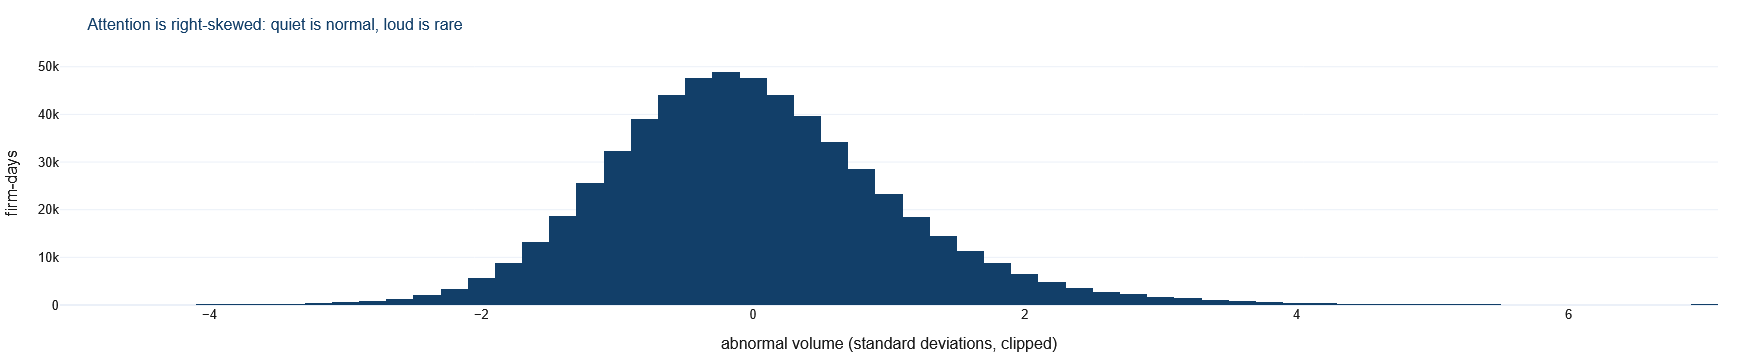

skewness            : 0.57
share above +2 sd   : 0.042
share below -2 sd   : 0.021

lag-1 autocorrelation, median across firms: 0.512


In [16]:
fig = go.Figure(go.Histogram(x=panel["abn_vol"].clip(-5, 7), nbinsx=90,
                             marker_color=airm7.NAVY))
fig.update_xaxes(title_text="abnormal volume (standard deviations, clipped)")
fig.update_yaxes(title_text="firm-days")
airm7.fig_layout(fig, "Attention is right-skewed: quiet is normal, loud is rare",
                 height=360, showlegend=False).show()

print(f"skewness            : {panel['abn_vol'].skew():.2f}")
print(f"share above +2 sd   : {(panel['abn_vol'] > 2).mean():.3f}")
print(f"share below -2 sd   : {(panel['abn_vol'] < -2).mean():.3f}")

ac = (panel.sort_values(['ticker', 'date'])
           .groupby('ticker', observed=True)['abn_vol']
           .apply(lambda s: s.autocorr(lag=1)))
print(f"\nlag-1 autocorrelation, median across firms: {ac.median():.3f}")

Attention is **persistent and one-sided**. A firm that was unusually talked about
yesterday is unusually talked about today, and the tail is on the loud side only —
there is a floor on how quiet a listed company can be, but no ceiling on how loud.

Both properties matter for what follows. Persistence means attention is a slow-moving
firm characteristic, so anything else that is a slow-moving firm characteristic
(size, coverage, liquidity, volatility) will correlate with it. That is precisely the
condition under which omitting it does damage.

## Part B — A panel where we know the answer

Now the experiment. We construct a firm-day panel in which **sentiment has exactly
zero effect on returns**, by construction:

$$
\begin{aligned}
A_{i,t} &\sim N(0,1) && \text{attention} \\
S_{i,t} &= \rho A_{i,t} + \sqrt{1-\rho^2}\,\varepsilon_{i,t} && \text{sentiment, correlated with attention} \\
r_{i,t} &= \underbrace{\beta}_{=\,0} S_{i,t} \;+\; \gamma A_{i,t} \;+\; \sigma u_{i,t} && \text{returns}
\end{aligned}
$$

Sentiment does nothing. It is correlated with attention, and attention moves returns.
That is the entire setup, and it is not a contrived one: any text-derived signal is
mechanically co-determined with how much text exists.

We calibrate the noise to the real panel so the numbers are on a realistic scale.

In [27]:
dates = panel["date"].drop_duplicates().sort_values()
sigma_real = panel.groupby("ticker", observed=True)["ret"].std().median()
n_firms = panel["ticker"].nunique()

print(f"calibrating to the real panel: "
      f"{n_firms} firms, {len(dates):,} days "
      f"({dates.iloc[0].date():%b %d, %Y} to {dates.iloc[-1].date()}), "   # '%b %d, %Y', '%B %d, %Y', and '%Y-%m-%d' are date format specifiers. Try different versions to see how the date is displayed.
      f"median daily return sd = {sigma_real:.4f}"                         # '.4f' is a numeric format specifier: display the number as a fixed-point decimal with 4 digits after the decimal point.
)

calibrating to the real panel: 483 firms, 1,228 days (Mar 26, 2013 to 2018-02-07), median daily return sd = 0.0143


In [28]:
sim = airm7.simulate_attention_panel(
    n_firms=n_firms, 
    dates=dates,
    beta_true=0.0,               # <-- sentiment does NOTHING
    gamma=0.35,                  # attention does move returns
    rho_sa=0.60,                 # sentiment and attention are correlated
    sigma_ret=float(sigma_real), # we take a median return volatility (we calculated it above)
    seed=7,
)

print(f"simulated panel: {len(sim):,} firm-days")
print(f"corr(sentiment, attention) = {sim['sentiment'].corr(sim['attention']):.3f}")

simulated panel: 593,124 firm-days
corr(sentiment, attention) = 0.600


In [29]:
sim

,ticker,date,sentiment,attention,ret
0,SIM000,2013-03-26,-1.696585,0.001230,0.007607
1,SIM001,2013-03-26,-0.992183,0.298746,0.119793
2,SIM002,2013-03-26,0.815656,-0.274138,-0.081674
3,SIM003,2013-03-26,0.731427,-0.890592,-0.330374
4,SIM004,2013-03-26,-0.151700,-0.454671,-0.145047
...,...,...,...,...,...
593119,SIM478,2018-02-07,0.664749,0.754910,0.289718
593120,SIM479,2018-02-07,1.007756,1.225980,0.424511
593121,SIM480,2018-02-07,0.828007,1.146540,0.385847
593122,SIM481,2018-02-07,-0.223510,0.518233,0.206922


You will need to **run the plotting code below** to generate the figures. I have not included the figure output because the resulting notebook file became **very large** (over 100 MB for the three figures below). With more than half a million observations, each plotted point must be stored in the figure, which substantially increases the file size.

In [ ]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3,subplot_titles=[
        "Attention vs Return",
        "Sentiment vs Return",
        "Attention vs Sentiment"
    ])

# Panel 1
fig.add_trace(go.Scattergl(
        x=sim["attention"],
        y=sim["ret"],
        mode="markers",
        marker=dict(size=2, opacity=0.25),
        showlegend=False,
    ), row=1, col=1)

# Panel 2
fig.add_trace(go.Scattergl(
        x=sim["sentiment"],
        y=sim["ret"],
        mode="markers",
        marker=dict(size=2, opacity=0.25),
        showlegend=False,
    ), row=1, col=2)

# Panel 3
fig.add_trace(go.Scattergl(
        x=sim["attention"],
        y=sim["sentiment"],
        mode="markers",
        marker=dict(size=2, opacity=0.25),
        showlegend=False,
    ), row=1, col=3)

fig.update_xaxes(title="Attention", row=1, col=1)
fig.update_yaxes(title="Return", row=1, col=1)

fig.update_xaxes(title="Sentiment", row=1, col=2)
fig.update_yaxes(title="Return", row=1, col=2)

fig.update_xaxes(title="Attention", row=1, col=3)
fig.update_yaxes(title="Sentiment", row=1, col=3)

fig.update_layout(height=450, width=1400, template="plotly_white",)
fig.show()

Notice that the same plotting code is **repeated several times with only minor changes**. This is a good opportunity to use a *for-loop* to **automate** the task and write more efficient, readable code.

In [ ]:
fig = make_subplots(rows=1, cols=3, subplot_titles=[
        "Attention vs Return",
        "Sentiment vs Return",
        "Attention vs Sentiment"
    ])

pairs = [
    ("attention", "ret"),
    ("sentiment", "ret"),
    ("attention", "sentiment"),
]

for i, (x, y) in enumerate(pairs, start=1):
    fig.add_trace(go.Histogram2d(
            x=sim[x],
            y=sim[y],
            colorscale="Viridis",
            nbinsx=60,
            nbinsy=60,
            showscale=False,
        ), row=1, col=i)

fig.update_layout(template="plotly_white", width=1400, height=450)
fig.show()

In [ ]:
fig = make_subplots(rows=1, cols=3, subplot_titles=[
        "Attention vs Return",
        "Sentiment vs Return",
        "Attention vs Sentiment"
    ])

pairs = [
    ("attention", "ret"),
    ("sentiment", "ret"),
    ("attention", "sentiment"),
]

for i, (x, y) in enumerate(pairs, start=1):
    fig.add_trace(go.Histogram2dContour(
            x=sim[x],
            y=sim[y],
            colorscale="Viridis",               # Try different colormaps from https://matplotlib.org/stable/users/explain/colors/colormaps.html
            contours=dict(showlabels=True),
            showscale=(i == 1),
        ), row=1, col=i)

fig.update_layout(template="plotly_white", width=1400, height=450)
fig.show()

### B1. The regression an analyst would actually run

You have a sentiment score and you have returns. You do not have a Buzz feed, because
your vendor does not sell you one. So you run the obvious regression.

In [37]:
naive = sm.OLS(sim["ret"], sm.add_constant(sim[["sentiment"]])).fit()

print(naive.summary().tables[1])
print(f"\nR-squared: {naive.rsquared:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.930      0.054   -1.08e-05       0.001
sentiment      0.2099      0.000    577.073      0.000       0.209       0.211

R-squared: 0.3596


### Stop and read that output.

A coefficient of that size, with that $t$-statistic, on 500,000-plus observations.
In any seminar this is a result. You would write it up.

**It is completely false.** We set $\beta = 0$ ourselves, some cells ago in our simulation setup.

The problem is not small samples.

The problem is not noisy data.

The problem is not statistical significance.

In fact, having 593,124 observations makes the situation worse, because the standard errors become tiny. The model becomes extremely confident about the wrong answer.

Large datasets cannot fix omitted variable bias. They simply allow us to estimate the wrong quantity more precisely.

> A biased estimate does not become correct when the sample size increases. It simply becomes more precisely wrong.

In [38]:
controlled = sm.OLS(sim["ret"], sm.add_constant(sim[["sentiment", "attention"]])).fit()
print(controlled.summary().tables[1])

print(f"\n{'':22s}{'beta':>12s}{'t-stat':>10s}")
print(f"{'without attention':22s}{naive.params['sentiment']:>12.5f}"
      f"{naive.tvalues['sentiment']:>10.1f}")
print(f"{'with attention':22s}{controlled.params['sentiment']:>12.5f}"
      f"{controlled.tvalues['sentiment']:>10.1f}")
print(f"{'TRUE value':22s}{0.0:>12.5f}{'-':>10s}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.489e-05   1.86e-05     -1.337      0.181   -6.14e-05    1.16e-05
sentiment  -3.426e-05   2.33e-05     -1.472      0.141   -7.99e-05    1.14e-05
attention      0.3500   2.33e-05    1.5e+04      0.000       0.350       0.350

                              beta    t-stat
without attention          0.20993     577.1
with attention            -0.00003      -1.5
TRUE value                 0.00000         -


**A useful analogy**

Imagine trying to determine whether carrying an umbrella causes traffic accidents.

Suppose rainy days have:
- more umbrellas, and
- more accidents.

A regression of accidents on umbrella usage alone would likely find a strong positive relationship.

But umbrellas are not causing the accidents.

The omitted variable is rain.

Once rain is included in the analysis, the apparent effect of umbrellas disappears.

In our simulation:
- sentiment is the umbrella,
- attention is the rain,
- returns are the accidents.

### B2. The bias is not a surprise — it is arithmetic

<details>
<summary><b>The maths (click to expand)</b></summary>

Suppose the correct model is

$$r = \beta S + \gamma A + u$$

but you estimate $r = b S + e$. The omitted term $\gamma A$ is absorbed into $e$, and
because $S$ and $A$ are correlated, $e$ is no longer orthogonal to $S$. The standard
result is

$$\operatorname{plim} \hat{b} \;=\; \beta \;+\; \gamma\,\frac{\operatorname{Cov}(S,A)}{\operatorname{Var}(S)}$$

The bias term has two factors, and **both** must be non-zero for trouble:

* $\gamma \ne 0$ — the omitted variable actually affects returns;
* $\operatorname{Cov}(S,A) \ne 0$ — it is correlated with your signal.

For a text-derived signal and attention, both hold essentially by construction. This
is not an edge case you might get unlucky with; it is the default state.

</details>

`airm7.omitted_variable_bias` computes the formula. Compare it to what we just
estimated.

In [39]:
predicted = airm7.omitted_variable_bias(sim, y="ret", x="sentiment", z="attention")
actual = naive.params["sentiment"] - 0.0

print(f"bias predicted by the formula : {predicted: .6f}")
print(f"bias actually observed        : {actual: .6f}")
print(f"difference                    : {abs(predicted-actual): .2e}")

bias predicted by the formula :  0.209966
bias actually observed        :  0.209932
difference                    :  3.43e-05


### B3. When does the sign flip?

So far the true effect was zero. Now give sentiment a genuine **positive** effect and
let attention work against it. Sweep the correlation $\rho$ between sentiment and
attention, and watch where the naive estimate crosses zero.

This is the frame from the lecture, drawn from your own data.

In [40]:
BETA_TRUE = 0.05          # sentiment genuinely helps, a little
rows = []
for rho in np.linspace(-0.9, 0.9, 19):
    s = airm7.simulate_attention_panel(
        n_firms=120, 
        dates=dates[::5], 
        beta_true=BETA_TRUE,
        gamma=-0.30,                       # attention pushes the other way
        rho_sa=float(rho), 
        sigma_ret=float(sigma_real), 
        seed=21,
    )
    b_naive = sm.OLS(s["ret"], sm.add_constant(s[["sentiment"]])).fit().params["sentiment"]
    b_ctrl = sm.OLS(s["ret"], sm.add_constant(s[["sentiment", "attention"]])).fit().params["sentiment"]
    rows.append({"rho": rho, "naive": b_naive, "controlled": b_ctrl})

sweep = pd.DataFrame(rows)

In [41]:
sweep

,rho,naive,controlled
0,-0.9,0.319166,0.049925
1,-0.8,0.288468,0.049945
2,-0.7,0.257980,0.049954
3,-0.6,0.227703,0.049959
4,-0.5,0.197622,0.049962
5,-0.4,0.167715,0.049964
6,-0.3,0.137957,0.049966
7,-0.2,0.108321,0.049966
8,-0.1,0.078779,0.049967
9,0.0,0.049300,0.049967


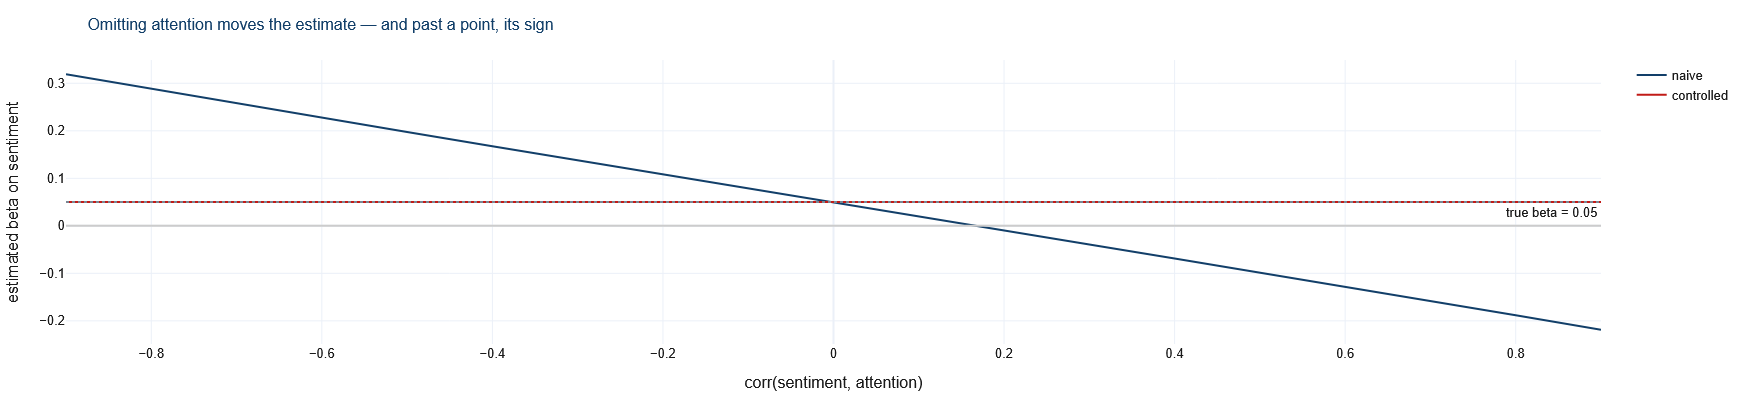

The naive estimate has the WRONG SIGN once corr(S, A) exceeds 0.20

Controlled estimate stays at the truth throughout: min 0.0499, max 0.0500


In [42]:
fig = airm7.plot_lines(sweep, "rho", ["naive", "controlled"],
                       title="Omitting attention moves the estimate — and past a point, its sign",
                       xlab="corr(sentiment, attention)", ylab="estimated beta on sentiment")
fig.add_hline(y=BETA_TRUE, line_dash="dot", line_color=airm7.GREY,
              annotation_text=f"true beta = {BETA_TRUE}", annotation_position="bottom right")
fig.add_hline(y=0, line_color="#cccccc")
fig.show()

flip = sweep[sweep["naive"] * BETA_TRUE < 0]
if len(flip):
    print(f"The naive estimate has the WRONG SIGN once corr(S, A) exceeds "
          f"{flip['rho'].min():.2f}")
print(f"\nControlled estimate stays at the truth throughout: "
      f"min {sweep['controlled'].min():.4f}, max {sweep['controlled'].max():.4f}")

Notice what the controlled line does: nothing. It sits on the true value across the
whole range. The control is not a robustness check you add to satisfy a referee — it
is the difference between an estimator that works and one that does not.

## Part C — The same arithmetic, on real data

We now have a procedure we trust, because we watched it recover a known truth. But
Part B also gave us something more useful than a procedure. It gave us a way to know
**in advance** how much omitting a control will cost.

Recall the bias term:

$$\operatorname{plim}\hat{b} - \beta \;=\; \gamma \cdot \underbrace{\frac{\operatorname{Cov}(S,A)}{\operatorname{Var}(S)}}_{\textstyle \delta}$$

$\delta$ is just the slope of a regression of attention on your signal. **You can
compute it before you run anything**, without knowing $\gamma$, without a return
series, without a single hypothesis test. It tells you how entangled your signal is
with attention, and therefore how much the control can possibly matter.

Let us test that on three real signals, none of which we constructed.

In [43]:
real = panel.sort_values(["ticker", "date"]).copy()
g = real.groupby("ticker", observed=True)

real["rev5"]  = -g["ret"].transform(lambda s: s.rolling(5).sum().shift(1))
real["mom21"] =  g["ret"].transform(lambda s: s.rolling(21).sum().shift(1))
real["range"] = (real["high"] - real["low"]) / real["close"]
real["hilo"]  =  g["range"].shift(1)         # yesterday's intraday range
real["fwd_ret"] = g["ret"].shift(-1)

# standardise cross-sectionally each day so coefficients are comparable
def _z(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd and np.isfinite(sd) else s * 0.0

for c in ["rev5", "mom21", "hilo", "abn_vol"]:
    real[c + "_z"] = real.groupby("date", observed=True)[c].transform(_z)
real = real.replace([np.inf, -np.inf], np.nan)

In [44]:
real

,date,open,high,low,close,volume,ticker,ret,logvol,abn_vol,rev5,mom21,range,hilo,fwd_ret,rev5_z,mom21_z,hilo_z,abn_vol_z
0,2013-03-26,41.40,41.8200,41.3200,41.82,2513554,A,0.016776,14.737209,-0.809590,NaN,NaN,0.011956,NaN,0.006456,NaN,NaN,NaN,-0.349367
1,2013-03-27,41.40,42.1900,41.2100,42.09,3369968,A,0.006456,15.030414,-0.062936,NaN,NaN,0.023283,0.011956,-0.002851,NaN,NaN,-0.384509,0.570823
2,2013-03-28,42.08,42.0800,41.4995,41.97,2147900,A,-0.002851,14.580002,-1.194589,NaN,NaN,0.013831,0.023283,-0.024780,NaN,NaN,0.836475,-1.222835
3,2013-04-01,41.83,41.9771,40.7900,40.93,2541331,A,-0.024780,14.748199,-0.731066,NaN,NaN,0.029003,0.013831,-0.006597,NaN,NaN,-0.353478,-0.130804
4,2013-04-02,41.12,41.3600,40.5900,40.66,2354390,A,-0.006597,14.671793,-0.907195,NaN,NaN,0.018938,0.029003,-0.003443,NaN,NaN,1.002881,-0.785702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592364,2018-02-01,76.84,78.2700,76.6900,77.82,2982259,ZTS,0.014206,14.908192,0.740991,0.020177,0.064266,0.020303,0.029063,-0.013364,0.278234,0.329467,0.408429,0.169605
592365,2018-02-02,77.53,78.1200,76.7300,76.78,2595187,ZTS,-0.013364,14.769170,0.424868,0.017716,0.082220,0.018104,0.020303,-0.038421,0.154022,0.725748,-0.380876,-0.378965
592366,2018-02-05,76.64,76.9200,73.1800,73.83,2962031,ZTS,-0.038421,14.901386,0.782695,0.041680,0.064257,0.050657,0.018104,-0.007585,-0.002470,0.845943,-0.736035,-0.745993
592367,2018-02-06,72.74,74.5600,72.1300,73.27,4924323,ZTS,-0.007585,15.409698,2.160690,0.068739,0.019872,0.033165,0.050657,0.008052,-0.057844,0.807222,-0.022833,0.592152


In [45]:
print("Entanglement with attention, computed BEFORE any regression:\n")
for s in ["rev5", "mom21", "hilo"]:
    d = real.dropna(subset=[s + "_z", "abn_vol_z"])
    delta = d[[s + "_z", "abn_vol_z"]].cov().iloc[0, 1] / d[s + "_z"].var()
    print(f"  {s:7s} delta = {delta:+.4f}")

Entanglement with attention, computed BEFORE any regression:

  rev5    delta = +0.0408
  mom21   delta = -0.0874
  hilo    delta = +0.1813


`hilo` — yesterday's intraday high-low range — is four times more entangled with
attention than a five-day reversal is. That should not be surprising: a wide range
and heavy volume are two views of the same eventful day.

Now run both regressions for each signal and check the prediction.

In [46]:
rows = []
for s in ["rev5", "mom21", "hilo"]:
    d = real.dropna(subset=[s + "_z", "abn_vol_z", "fwd_ret"])
    m_naive = sm.OLS(d["fwd_ret"], sm.add_constant(d[[s + "_z"]])).fit(
        cov_type="cluster", cov_kwds={"groups": d["date"]})
    m_ctrl = sm.OLS(d["fwd_ret"], sm.add_constant(d[[s + "_z", "abn_vol_z"]])).fit(
        cov_type="cluster", cov_kwds={"groups": d["date"]})

    gamma = m_ctrl.params["abn_vol_z"]
    delta = d[[s + "_z", "abn_vol_z"]].cov().iloc[0, 1] / d[s + "_z"].var()
    rows.append({
        "signal": s, "delta": delta,
        "beta_naive_bp": m_naive.params[s + "_z"] * 1e4,
        "t_naive": m_naive.tvalues[s + "_z"],
        "beta_ctrl_bp": m_ctrl.params[s + "_z"] * 1e4,
        "t_ctrl": m_ctrl.tvalues[s + "_z"],
        "predicted_shift_bp": gamma * delta * 1e4,
        "actual_shift_bp": (m_naive.params[s + "_z"] - m_ctrl.params[s + "_z"]) * 1e4,
    })

res = pd.DataFrame(rows)
print("Next-day return, SEs clustered by date. Shifts in basis points.\n")
print(res.round(4).to_string(index=False))

Next-day return, SEs clustered by date. Shifts in basis points.

signal   delta  beta_naive_bp  t_naive  beta_ctrl_bp  t_ctrl  predicted_shift_bp  actual_shift_bp
  rev5  0.0408         0.8573   1.3854        0.8403  1.3574              0.0170           0.0170
 mom21 -0.0874        -0.8897  -1.3466       -0.8605 -1.3040             -0.0291          -0.0291
  hilo  0.1814         0.9688   1.3415        0.9124  1.2479              0.0564           0.0564


### The prediction is exact — and that is the point

The predicted and actual shifts agree to the last decimal place shown. This is not a
lucky empirical finding: for OLS the relationship is an **algebraic identity in
sample**, not merely an asymptotic result. It has to hold.

Which is precisely what makes it useful. It means:

> **You never have to guess whether an omitted control matters.** Regress the control
> on your signal, look at $\delta$, and you have bounded the damage before you have
> run a single hypothesis test.

For these three price-based signals, $\delta$ is small — between 0.04 and 0.18 — so
the control shifts the coefficient by a fraction of a basis point and changes no
conclusions. **That is a real answer, not a failed experiment.** Attention is only
mildly entangled with a reversal signal.

Now consider what $\delta$ would look like for a **text-derived** signal. Sentiment
is computed *from* the text; Buzz is the *count* of that same text. They share a
denominator. In the ESG panel from the lecture, adding $\log(1+\text{Buzz})$ raised
the explained variation in the score from 20.5% to 33.4% — an entanglement far beyond
anything on this table. That is why the sign can flip there and does not here.

### What you can and cannot say

**You can say:** the shift is exactly what the formula predicts, on data nobody
constructed, and it is small for these signals because $\delta$ is small.

**You cannot say:** which estimate is correct. In Part B you could, because you set
the truth. Here you cannot, and more data will not fix it — it is not a sample-size
problem.

That asymmetry is why the simulation came first, and why the lecture's claim was
phrased as *"omitting Buzz **can** flip the sign"* rather than *"the sign is wrong"*.

> **The transferable rule:** if a specification choice moves your coefficient by more
> than its standard error, that choice **is** part of your result and belongs in the
> table, not in a footnote.

## Exercises

### Core

1. **Vary the window.** `add_abnormal_volume` defaults to 60 days. Redo Part C at 20
   and 120. How much does `delta` depend on the window length you chose?
2. **Dollar volume.** Replace share volume with `close * volume` before taking logs.
   Does the attention measure behave differently, and what happens to `delta`?
3. **Break the correlation.** In Part B, set `rho_sa=0.0` and re-run B1. Confirm the
   naive estimate is now unbiased, and explain in one sentence which factor of the
   bias formula you just switched off.

### Stretch

4. **Non-linear attention.** The lecture argued that low Buzz *mechanically* polarises
   a score. Modify the simulation so the variance of `sentiment` falls with attention
   — sparse coverage, extreme scores — rather than only its mean. Is the naive
   estimator still biased? Is it biased in the same direction?
5. **Firm fixed effects.** Attention is highly persistent, so much of its variation is
   cross-sectional. Add firm fixed effects to Part C via demeaning. How much of the
   attention effect survives, and what does that tell you about whether attention is a
   *state* or a *characteristic*?
6. **Real text attention.** Wikipedia pageviews are free, need no key, and go back to
   2015: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/{article}/daily/{start}/{end}`.
   Pull daily views for twenty S&P 500 firms, build the same standardised measure, and
   check how well it correlates with abnormal volume. If the two attention proxies
   disagree, which one belongs in the regression — and how would you decide?

---

## Carry forward to Lec07c

Parts A to C assumed your scorer is honest. Lec07c asks whether it is: whether an
apparently skilful model is reading the text in front of it, or remembering what
happened next.